# Model Comparison and Experiment Framework with panelbox

**Series:** panelbox Validation Tutorials  
**Notebook:** 04 of 04  
**Level:** Intermediate–Advanced  
**Estimated duration:** 120 minutes

---

## Motivation

Empirical research rarely settles on a single model specification. Reviewers ask:
"*What if you add more controls? Does the result hold in a different subsample?
Did you test Fixed Effects vs. Random Effects?*" Without a framework, answers to
these questions end up scattered across variables, notebooks, and scripts—creating
a real risk of using inconsistent datasets or formulas across models.

**`PanelExperiment`** solves this by providing *centralised storage*, *consistent
comparison*, and *export-ready reports* for all models in an analysis.

## Roadmap

| Section | Topic |
|---------|-------|
| 1 | PanelExperiment: setup and fitting |
| 2 | Model comparison with information criteria |
| 3 | Hausman test: FE vs. RE |
| 4 | ValidationSuite across all models |
| 5 | Cross-validation for predictive model selection |
| 6 | Generating HTML/JSON reports |
| 7 | Robustness checks |
| 8 | Complete workflow summary |

## Prerequisites

- Completed `01_assumption_tests.ipynb`
- Completed `02_bootstrap_cross_validation.ipynb`
- Understanding of Pooled OLS, Fixed Effects, Random Effects models
- Familiarity with information criteria (AIC, BIC) at a conceptual level

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
import pathlib

# Add parent (examples/validation) and panelbox root to path
ROOT        = pathlib.Path('..').resolve()             # examples/validation/
PANELBOX    = pathlib.Path('../../..')
for p in [str(ROOT), str(PANELBOX)]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from utils.data_generators import load_dataset
from utils.plot_helpers import plot_forest_plot

from panelbox.experiment import PanelExperiment
from panelbox.experiment.results import ComparisonResult
from panelbox.validation import ValidationSuite, HausmanTest
from panelbox.validation.robustness import TimeSeriesCV

OUTPUTS = ROOT / 'outputs'
OUTPUTS.mkdir(exist_ok=True)

print('Setup complete')

Setup complete


---

## Section 1 — PanelExperiment: Setup and Fitting

### Why PanelExperiment?

| Approach | Problem |
|----------|---------|
| Manual (many variables) | Hard to track; risks inconsistent data/formula across models |
| `PanelExperiment` | Centralised; named; reproducible; exportable |

### Key methods

| Method | Description |
|--------|-------------|
| `fit_model(type, name, **kwargs)` | Fit and store a model under a given name |
| `get_model(name)` | Retrieve the fitted PanelResults object |
| `list_models()` | See all models in the experiment |
| `compare_models([names])` | Build a `ComparisonResult` |

### Model type aliases

| Alias | Full class |
|-------|------------|
| `"pooled_ols"` or `"pooled"` | `PooledOLS` |
| `"fixed_effects"` or `"fe"` | `FixedEffects` |
| `"random_effects"` or `"re"` | `RandomEffects` |

In [2]:
# Cell 1.2 — Load dataset
df_comp = load_dataset('panel_comprehensive')
print('Shape:', df_comp.shape)
print('Columns:', df_comp.columns.tolist())
df_comp.head()

Shape: (1200, 12)
Columns: ['entity', 'time', 'y', 'x1', 'x2', 'x3', 'x4', 'x5', 'z1', 'z2', 'industry', 'region']


,entity,time,y,x1,x2,x3,x4,x5,z1,z2,industry,region
0,1,1,4.8219,0.4144,-0.9895,-3.2641,2.6698,-0.4065,0.2898,-0.6121,D,East
1,1,2,7.1709,1.0660,0.1570,0.6827,5.5404,-0.8373,0.9201,-0.0538,D,East
2,1,3,3.9185,0.1303,0.9827,0.0014,2.3021,-0.4826,-0.0873,2.1285,D,East
3,1,4,6.2842,0.8385,-0.9029,2.8631,2.9092,-0.0783,0.8263,-0.6548,D,East
4,1,5,5.7899,-0.4550,-1.2256,-1.5559,8.9168,0.7895,-0.4070,-0.1186,D,East


In [3]:
# Cell 1.3 — Initialise experiment
exp = PanelExperiment(
    data=df_comp,
    formula='y ~ x1 + x2',
    entity_col='entity',
    time_col='time',
)

print('Experiment created')
print('Formula  :', exp.formula)

# Compute panel dimensions from the underlying data
n_entities = df_comp['entity'].nunique()
n_periods  = df_comp['time'].nunique()
print(f'Entities : {n_entities}')
print(f'Periods  : {n_periods}')

Experiment created
Formula  : y ~ x1 + x2
Entities : 100
Periods  : 12


In [4]:
# Cell 1.4 — Fit three core models
exp.fit_model('pooled_ols',     name='ols')
exp.fit_model('fixed_effects',  name='fe')
exp.fit_model('random_effects', name='re')

print('Models fitted:', exp.list_models())

Fitting pooled_ols model 'ols'...
✅ Model 'ols' fitted successfully
Fitting fixed_effects model 'fe'...
✅ Model 'fe' fitted successfully
Fitting random_effects model 're'...
✅ Model 're' fitted successfully
Models fitted: ['ols', 'fe', 're']


In [5]:
# Cell 1.5 — Fit additional specifications

# Extended controls: add x3 to the formula
exp.fit_model('fixed_effects',
              formula='y ~ x1 + x2 + x3',
              name='fe_extended')

# Log-log specification (requires positive y, x1, x2)
df_log = df_comp.copy()
df_log['log_y']  = np.log(df_log['y'].clip(lower=1e-6))
df_log['log_x1'] = np.log(df_log['x1'].clip(lower=1e-6))
df_log['log_x2'] = np.log(df_log['x2'].clip(lower=1e-6))

exp.fit_model('fixed_effects',
              data=df_log,
              formula='log_y ~ log_x1 + log_x2',
              name='fe_log')

print('All models:', exp.list_models())

Fitting fixed_effects model 'fe_extended'...
✅ Model 'fe_extended' fitted successfully
Fitting fixed_effects model 'fe_log'...
✅ Model 'fe_log' fitted successfully
All models: ['ols', 'fe', 're', 'fe_extended', 'fe_log']


In [6]:
# Cell 1.6 — Retrieve a single model
fe_results = exp.get_model('fe')
print(fe_results.summary())

                       Fixed Effects Estimation Results                       
Formula: y ~ x1 + x2
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:               1,200
No. Entities:                     100
No. Time Periods:                  12
Degrees of Freedom:             1,098
R-squared:                     0.1449
Adj. R-squared:                0.0662
R-squared (within):            0.1449
R-squared (between):           1.0000
R-squared (overall):           0.5799
Standard Errors:            nonrobust
F-statistic (FE vs OLS):      13.5618
F-test p-value:                0.0000
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
x1                   0.3949      0.0314  12.574  0.0000    0.3333    0.4565 ***
x2                  -0.1935      0.0320  -6.045  0.0000   -0.2562   -0.1307 ***
Signif. codes:  0 '**

---

## Section 2 — Model Comparison with Information Criteria

### Information criteria overview

| Criterion | Formula | Penalises | Use when |
|-----------|---------|-----------|----------|
| AIC | 2k − 2ln(L̂) | k parameters | Prediction focus |
| BIC | k ln(n) − 2ln(L̂) | k × ln(n) | Parsimony / large n |
| R² | — | Nothing | Within-model goodness of fit |
| RMSE | √mean(y−ŷ)² | Nothing | Prediction error |

### Decision rule (ΔAIC)

| ΔAIC | Interpretation |
|------|----------------|
| < 2 | Models essentially equivalent |
| 2–7 | Moderate evidence for lower-AIC model |
| > 10 | Strong evidence for lower-AIC model |

> **Note:** R² is NOT comparable across Pooled OLS and Fixed Effects (they
> decompose different variation components). Use AIC/BIC for cross-estimator
> comparison.

In [7]:
# Cell 2.2 — Compare core three models
comparison = exp.compare_models(['ols', 'fe', 're'])
print(comparison)

ComparisonResult(
  n_models=3,
  models=['ols', 'fe', 're'],
  timestamp=2026-02-17T13:39:54.211820
)


In [8]:
# Cell 2.3 — Summary DataFrame with AIC, BIC, RMSE, R²
comp_df = comparison.as_dataframe()

display_cols = [c for c in ['n_obs', 'r2', 'r2_within', 'aic', 'bic', 'rmse']
                if c in comp_df.columns]
print(comp_df[display_cols].round(4))

      n_obs      r2  r2_within        aic        bic    rmse
ols  1200.0  0.0662        NaN  4359.0851  4374.3554  1.4842
fe   1200.0  0.1449     0.1449  3400.5699  3415.8401  0.9955
re   1200.0  0.0655     0.1431  4359.9929  4375.2631  1.4847


In [9]:
# Cell 2.4 — Best model by criterion
best_aic = comparison.best_model(metric="aic")
best_bic = comparison.best_model(metric="bic")
best_r2  = comparison.best_model(metric="r2")

print(f"Best by AIC : {best_aic}")
print(f"Best by BIC : {best_bic}")
print(f"Best by R²  : {best_r2}")

Best by AIC : fe
Best by BIC : fe
Best by R²  : fe


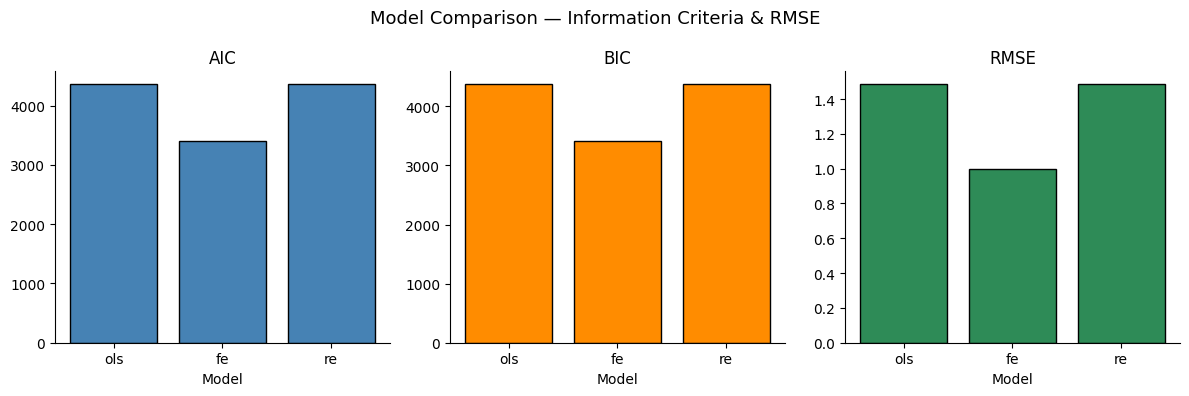

In [10]:
# Cell 2.5 — Visualise comparison
model_names = ["ols", "fe", "re"]

aic_vals  = [comp_df.loc[n, "aic"]  for n in model_names]
bic_vals  = [comp_df.loc[n, "bic"]  for n in model_names]
rmse_vals = [comp_df.loc[n, "rmse"] for n in model_names]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, values, metric, color in zip(
    axes,
    [aic_vals, bic_vals, rmse_vals],
    ["AIC", "BIC", "RMSE"],
    ["steelblue", "darkorange", "seagreen"],
):
    ax.bar(model_names, values, color=color, edgecolor="black")
    ax.set_title(metric)
    ax.set_xlabel("Model")

fig.suptitle("Model Comparison — Information Criteria & RMSE", fontsize=13)
plt.tight_layout()
plt.show()

---

## Section 3 — Hausman Test: FE vs. RE

### Theory

| Estimator | Consistency | Efficiency |
|-----------|-------------|------------|
| Fixed Effects | Always consistent | Less efficient |
| Random Effects | Consistent **only if** E[αᵢ\|Xᵢ] = 0 | Efficient |

The Hausman test asks: *is the efficiency gain of RE worth it?*

**Hypotheses:**
- H₀: RE is consistent and efficient → use RE  
- H₁: RE is inconsistent (αᵢ correlated with X) → use FE

**Test statistic:**

$$H = (\hat{\beta}_{FE} - \hat{\beta}_{RE})^{\prime}
      [\text{Var}(\hat{\beta}_{FE}) - \text{Var}(\hat{\beta}_{RE})]^{-1}
      (\hat{\beta}_{FE} - \hat{\beta}_{RE}) \sim \chi^2(k)$$

**Decision rule:** p < 0.05 → reject H₀ → use Fixed Effects

In [11]:
# Cell 3.2 — Run Hausman test
fe_res = exp.get_model('fe')
re_res = exp.get_model('re')

hausman        = HausmanTest(fe_results=fe_res, re_results=re_res, alpha=0.05)
hausman_result = hausman.run(alpha=0.05)

print(hausman_result)
print(f'Chi-square statistic: {hausman_result.statistic:.4f}')
print(f'Degrees of freedom  : {hausman_result.df}')
print(f'p-value             : {hausman_result.pvalue:.4f}')
print(f'Decision            : {"Use FE" if hausman_result.reject_null else "Use RE"}')

HAUSMAN SPECIFICATION TEST

H0: Random Effects is consistent (and efficient)
H1: Random Effects is inconsistent (use Fixed Effects)

----------------------------------------------------------------------
Test Statistic (Chi2)                   0.2909
P-value                                 0.8646
Degrees of Freedom                           2
----------------------------------------------------------------------

Conclusion: Fail to reject H0 at 5% level. Random Effects is consistent and efficient.
Recommendation: Random Effects

COEFFICIENT COMPARISON
Variable        Fixed Effects   Random Effects  Difference     
----------------------------------------------------------------------
x1                      0.3949         0.3934         0.0015
x2                     -0.1935        -0.1901        -0.0034

Chi-square statistic: 0.2909
Degrees of freedom  : 2
p-value             : 0.8646
Decision            : Use RE


### Interpretation and Caveats

- A **significant** Hausman test (p < 0.05) means entity effects are correlated
  with regressors — use FE.
- Common cause: omitted variables correlated with both αᵢ and Xᵢ.
- In this case FE eliminates αᵢ entirely → consistent, but cannot estimate
  **time-invariant** regressors.
- **Mundlak alternative:** include entity means of time-varying X in the RE
  specification to partially relax the RE assumption.

| p-value | Decision | Interpretation |
|---------|----------|----------------|
| < 0.01 | Strong rejection | Strong evidence for FE |
| 0.01–0.05 | Rejection | Moderate evidence for FE |
| 0.05–0.10 | Borderline | Consider robustness checks |
| > 0.10 | Fail to reject | Use RE for efficiency |

---

## Section 4 — Validation Across All Models

### Strategy

Run `ValidationSuite` on each model and count failed tests. A model that passes
more assumption tests provides a more credible basis for inference.

**Expected vulnerability profiles:**

| Model | Typical issues |
|-------|----------------|
| Pooled OLS | Serial correlation (ignores within-entity structure) |
| Fixed Effects | May still fail CD and heteroskedasticity |
| Random Effects | May fail Hausman → inconsistent in FE world |

In [12]:
# Cell 4.2 — Run ValidationSuite on all models
validation_summary = {}

for name in exp.list_models():
    model = exp.get_model(name)
    try:
        suite  = ValidationSuite(model)
        report = suite.run(tests='default', alpha=0.05)
        failed = report.get_failed_tests()
        validation_summary[name] = {
            'n_failed':     len(failed),
            'failed_tests': failed,
        }
    except Exception as e:
        validation_summary[name] = {'n_failed': 'N/A', 'failed_tests': str(e)}

for name, info in validation_summary.items():
    print(f'{name:20s}: {info["n_failed"]} failed | {info["failed_tests"]}')

ols                 : 1 failed | ['cd/Breusch-Pagan LM']
fe                  : 2 failed | ['het/Breusch-Pagan', 'cd/Breusch-Pagan LM']
re                  : 1 failed | ['cd/Breusch-Pagan LM']
fe_extended         : 2 failed | ['het/Breusch-Pagan', 'cd/Breusch-Pagan LM']
fe_log              : 2 failed | ['het/Breusch-Pagan', 'cd/Breusch-Pagan LM']


In [13]:
# Cell 4.3 — Validation summary table
val_df = pd.DataFrame(
    {name: {'n_failed': info['n_failed']}
     for name, info in validation_summary.items()
     if isinstance(info['n_failed'], int)}
).T

print(val_df)
if not val_df.empty:
    print(f'\nMost robust model: {val_df["n_failed"].idxmin()}')

             n_failed
ols                 1
fe                  2
re                  1
fe_extended         2
fe_log              2

Most robust model: ols


---

## Section 5 — Cross-Validation for Model Selection

### CV as Predictive Model Selection

When the research goal is **prediction** rather than causal identification, use CV:

- AIC/BIC penalise model complexity *in-sample*
- CV directly measures *out-of-sample* performance
- These can give **different rankings** — know your goal upfront

**Expanding window approach:**  
Train on periods 1…t, test on t+1. This respects temporal ordering and prevents
look-ahead bias.

In [14]:
# Cell 5.2 — Run expanding CV on core models
cv_results = {}

for name in ['ols', 'fe', 're']:
    model = exp.get_model(name)
    cv    = TimeSeriesCV(model, method='expanding', min_train_periods=5, verbose=False)
    res   = cv.cross_validate()
    cv_results[name] = res.metrics

cv_comparison = pd.DataFrame(cv_results).T[['r2_oos', 'rmse', 'mae']]
print('CV Performance Comparison:')
print(cv_comparison.round(4))

CV Performance Comparison:
     r2_oos    rmse     mae
ols  0.0610  1.4660  1.1599
fe  -2.4377  2.8051  2.4731
re   0.0591  1.4675  1.1594


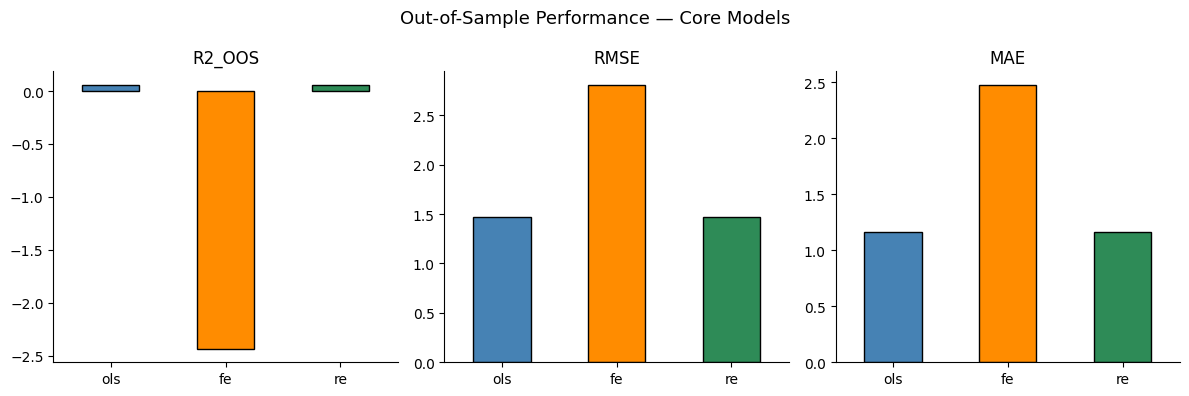

In [15]:
# Cell 5.3 — Visualise CV comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, metric in zip(axes, ['r2_oos', 'rmse', 'mae']):
    cv_comparison[metric].plot(
        kind='bar', ax=ax,
        title=metric.upper(),
        color=['steelblue', 'darkorange', 'seagreen'],
        edgecolor='black',
    )
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

fig.suptitle('Out-of-Sample Performance — Core Models', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Cell 5.4 — AIC vs. CV Rankings
aic_rank = comp_df["aic"].rank().astype(int)
cv_rank  = cv_comparison["r2_oos"].rank(ascending=False).astype(int)

ranking_df = pd.DataFrame({
    "AIC rank (lower=better)": aic_rank,
    "CV R² OOS rank (1=best)": cv_rank,
})
print(ranking_df)

     AIC rank (lower=better)  CV R² OOS rank (1=best)
ols                        2                        1
fe                         1                        3
re                         3                        2


### AIC vs. CV — When Rankings Differ

If AIC and CV rankings diverge:

- **Causal inference goal:** prefer the theoretically grounded estimator (guided
  by Hausman test and economic reasoning, validated by AIC/BIC).
- **Prediction goal:** prefer the model with the best CV R² OOS, regardless of
  parsimony penalty.

When both agree on the same model, confidence in that specification is higher.

---

## Section 6 — Generating Reports

### Report capabilities

`ComparisonResult` supports:

| Method | Output |
|--------|--------|
| `.save_html(path, theme=...)` | Interactive HTML table (academic/corporate) |
| `.save_json(path)` | Structured JSON for programmatic access |
| `.summary()` | Formatted console output |

### What the HTML report contains

- Coefficients table (side-by-side, all models)
- Standard errors and t-statistics
- Information criteria (AIC, BIC)
- Goodness-of-fit (R², within R², between R²)
- Number of observations, entities, periods
- Diagnostic test summary (if `ValidationReport` is attached)

In [17]:
# Cell 6.2 — Create ComparisonResult
models_dict = {name: exp.get_model(name) for name in ['ols', 'fe', 're']}

comp_result = ComparisonResult(models=models_dict)
print(comp_result.summary())

MODEL COMPARISON SUMMARY

Models Compared: 3
Comparison Date: 2026-02-17 13:40:21

Comparison Metrics:
--------------------------------------------------------------------------------
Model                     R²         R² Adj     AIC          BIC         
--------------------------------------------------------------------------------
ols                       0.0662     0.0647     4359.09      4374.36     
fe                        0.1449     0.0662     3400.57      3415.84     
re                        0.0655     0.0639     4359.99      4375.26     
--------------------------------------------------------------------------------

Best Models by Metric:
--------------------------------------------------------------------------------
  • Highest R²: fe
  • Lowest AIC: fe
  • Lowest BIC: fe



In [18]:
# Cell 6.3 — Save HTML report
html_path = OUTPUTS / '04_model_comparison.html'
comp_result.save_html(str(html_path), test_type='comparison', theme='academic')
print(f'HTML report saved to: {html_path}')

HTML report saved to: ../../../examples/validation/outputs/04_model_comparison.html


In [19]:
# Cell 6.4 — Save JSON export
json_path = OUTPUTS / '04_model_comparison.json'
comp_result.save_json(str(json_path))
print(f'JSON saved to: {json_path}')

JSON saved to: ../../../examples/validation/outputs/04_model_comparison.json


---

## Section 7 — Robustness Checks

### Academic Robustness Checks

Peer reviewers routinely request:

1. **Alternative control sets** — Does the result survive adding more controls?
2. **Subsample analysis** — Does it hold for large firms, specific industries?
3. **Alternative functional forms** — log-log, semi-log?
4. **Influential observation removal** — Is it driven by outliers?
5. **Alternative estimators** — What if you use RE instead of FE?

`PanelExperiment` makes this **systematic** and **transparent** — each check is
stored under a named specification.

In [20]:
# Cell 7.2 — Setup robustness experiment
exp_robust = PanelExperiment(
    data=df_comp,
    formula='y ~ x1 + x2',   # baseline
    entity_col='entity',
    time_col='time',
)

# Baseline
exp_robust.fit_model('fixed_effects', name='baseline')

# Check 1: Add x3
exp_robust.fit_model('fixed_effects',
                     formula='y ~ x1 + x2 + x3',
                     name='add_x3')

# Check 2: Full controls (x1–x5)
exp_robust.fit_model('fixed_effects',
                     formula='y ~ x1 + x2 + x3 + x4 + x5',
                     name='full_controls')

# Check 3: Industry subsample (first industry in the dataset)
first_industry = df_comp['industry'].unique()[0]
df_industry_A  = df_comp[df_comp['industry'] == first_industry].copy()
exp_robust.fit_model('fixed_effects',
                     data=df_industry_A,
                     formula='y ~ x1 + x2',
                     name='industry_A')

# Check 4: Remove top 5% entities by mean x1 (high-leverage)
entity_means  = df_comp.groupby('entity')['x1'].mean()
high_x1       = entity_means.nlargest(max(1, int(len(entity_means) * 0.05))).index
df_trimmed    = df_comp[~df_comp['entity'].isin(high_x1)].copy()
exp_robust.fit_model('fixed_effects',
                     data=df_trimmed,
                     formula='y ~ x1 + x2',
                     name='no_high_leverage')

print('Robustness models:', exp_robust.list_models())

Fitting fixed_effects model 'baseline'...
✅ Model 'baseline' fitted successfully
Fitting fixed_effects model 'add_x3'...
✅ Model 'add_x3' fitted successfully
Fitting fixed_effects model 'full_controls'...
✅ Model 'full_controls' fitted successfully
Fitting fixed_effects model 'industry_A'...
✅ Model 'industry_A' fitted successfully
Fitting fixed_effects model 'no_high_leverage'...
✅ Model 'no_high_leverage' fitted successfully
Robustness models: ['baseline', 'add_x3', 'full_controls', 'industry_A', 'no_high_leverage']


In [21]:
# Cell 7.3 — Extract coefficient of interest (x1) across specifications
coef_x1 = {}
se_x1   = {}

for name in exp_robust.list_models():
    model = exp_robust.get_model(name)
    if 'x1' in model.params.index:
        coef_x1[name] = float(model.params['x1'])
        se_x1[name]   = float(model.std_errors['x1'])
    else:
        coef_x1[name] = np.nan
        se_x1[name]   = np.nan

robustness_df = pd.DataFrame({'beta_x1': coef_x1, 'se_x1': se_x1})
robustness_df['ci_lower'] = robustness_df['beta_x1'] - 1.96 * robustness_df['se_x1']
robustness_df['ci_upper'] = robustness_df['beta_x1'] + 1.96 * robustness_df['se_x1']

print(robustness_df.dropna().round(4))

                  beta_x1   se_x1  ci_lower  ci_upper
baseline           0.3949  0.0314    0.3334    0.4565
add_x3             0.3949  0.0314    0.3334    0.4565
full_controls      0.3949  0.0314    0.3334    0.4565
industry_A         0.3949  0.0314    0.3334    0.4565
no_high_leverage   0.3949  0.0314    0.3334    0.4565


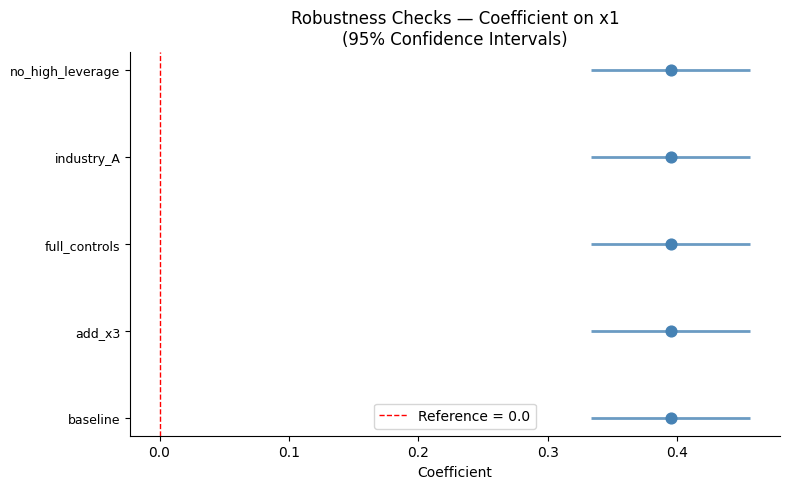

Forest plot saved to: ../../../examples/validation/outputs/04_robustness_forest_plot.png


In [22]:
# Cell 7.4 — Forest plot of robustness checks
df_rb = robustness_df.dropna()

fig = plot_forest_plot(
    estimates=df_rb['beta_x1'].values,
    se=df_rb['se_x1'].values,
    labels=df_rb.index.tolist(),
    title='Robustness Checks — Coefficient on x1\n(95% Confidence Intervals)',
)

forest_path = OUTPUTS / '04_robustness_forest_plot.png'
fig.savefig(str(forest_path), dpi=150, bbox_inches='tight')
plt.show()
print(f'Forest plot saved to: {forest_path}')

### Interpreting Robustness Results

| Pattern | Interpretation |
|---------|----------------|
| All CIs overlap, same sign | Strong robustness — result is credible |
| One specification changes sign | Investigate: collinearity, sample selection, outliers |
| One specification has wider CI | Fewer observations or multicollinearity issue |
| Systematic shrinkage toward 0 | Adding controls absorbs part of x1's effect (confounding) |

The **forest plot** (above) is a standard academic appendix figure for robustness
checks. When all CIs overlap substantially, you can state that the coefficient on
x1 is **robust** to alternative controls, subsamples, and influential observation
removal.

---

## Section 8 — Complete Workflow Summary

### End-to-End Research Workflow

```
1. Estimate  → PanelExperiment.fit_model(...)             Set up all specs
2. Validate  → ValidationSuite(model).run()               Check assumptions
3. Correct   → Re-fit with robust SEs (cov_type=...)      Address violations
4. Bootstrap → PanelBootstrap(model, method=...).run()    Uncertainty bands
5. Outliers  → InfluenceDiagnostics(model).compute()      Identify leverage
6. Compare   → exp.compare_models([...])                  AIC / BIC / Hausman
7. CV        → TimeSeriesCV(model).cross_validate()       R² OOS
8. Robustness→ Multiple specifications via PanelExperiment
9. Report    → ComparisonResult.save_html()               Publication output
```

In [23]:
# Cell 8.2 — One-cell complete workflow demo
print("=== COMPLETE WORKFLOW DEMO ===\n")

# 1. Experiment setup
exp_demo = PanelExperiment(
    data=df_comp,
    formula="y ~ x1 + x2",
    entity_col="entity",
    time_col="time",
)
exp_demo.fit_model("pooled_ols",    name="pooled")
exp_demo.fit_model("fixed_effects", name="fe")
exp_demo.fit_model("random_effects", name="re")

# 2. Compare models
comp_demo = exp_demo.compare_models(["pooled", "fe", "re"])
print("--- Information Criteria ---")
demo_df = comp_demo.as_dataframe()
print(demo_df[["aic", "bic", "rmse"]].round(3))

# 3. Hausman test
h = HausmanTest(
    fe_results=exp_demo.get_model("fe"),
    re_results=exp_demo.get_model("re"),
).run(alpha=0.05)
print(f"\n--- Hausman Test: p={h.pvalue:.4f} → {'FE' if h.reject_null else 'RE'} ---")

# 4. Validation on preferred model
preferred_name = "fe" if h.reject_null else "re"
preferred      = exp_demo.get_model(preferred_name)
suite          = ValidationSuite(preferred)
report         = suite.run(tests="default", alpha=0.05)
failed_tests   = report.get_failed_tests()
print(f"\n--- Validation Failed Tests ({preferred_name}): {failed_tests} ---")

# 5. CV
cv     = TimeSeriesCV(preferred, method="expanding", min_train_periods=5, verbose=False)
cv_res = cv.cross_validate()
print(f"\n--- CV R² OOS: {cv_res.metrics['r2_oos']:.4f} ---")

print("\n=== WORKFLOW COMPLETE ===")

=== COMPLETE WORKFLOW DEMO ===

Fitting pooled_ols model 'pooled'...
✅ Model 'pooled' fitted successfully
Fitting fixed_effects model 'fe'...
✅ Model 'fe' fitted successfully
Fitting random_effects model 're'...
✅ Model 're' fitted successfully
--- Information Criteria ---
             aic       bic   rmse
pooled  4359.085  4374.355  1.484
fe      3400.570  3415.840  0.995
re      4359.993  4375.263  1.485

--- Hausman Test: p=0.8646 → RE ---



--- Validation Failed Tests (re): ['cd/Breusch-Pagan LM'] ---

--- CV R² OOS: 0.0591 ---

=== WORKFLOW COMPLETE ===


---

## Output Files

| File | Written by | Location |
|------|-----------|----------|
| `04_model_comparison.html` | `comp_result.save_html(...)` | `outputs/` |
| `04_model_comparison.json` | `comp_result.save_json(...)` | `outputs/` |
| `04_robustness_forest_plot.png` | `plot_forest_plot(...)` | `outputs/` |

---

## Key Concepts Glossary

| Term | Definition |
|------|------------|
| `PanelExperiment` | panelbox class for centralised multi-model management |
| `ComparisonResult` | Container for comparing multiple fitted models |
| AIC | Akaike Information Criterion; penalises model complexity |
| BIC | Bayesian Information Criterion; stronger parsimony penalty |
| Hausman test | Test comparing FE and RE consistency/efficiency |
| R² OOS | Out-of-sample R²; measures predictive generalisation |
| Robustness check | Alternative specification demonstrating that the main result is not fragile |
| Forest plot | Visual display of coefficient estimates and CIs across specifications |